# Notebook 02 — Entraînement du modèle Pricing

**Objectif :** Prédire la fourchette de prix `[p_min, p_max]` pour une nouvelle demande.

**Approche :** LightGBM Quantile Regression
- Modèle Q25 → prédit `p_min` (borne basse)
- Modèle Q75 → prédit `p_max` (borne haute)

**MLflow** : chaque run est tracké automatiquement (params, métriques, modèle sauvegardé)

---
**Plan :**
1. Chargement des données
2. Feature engineering
3. Split train/test
4. Entraînement avec MLflow tracking
5. Évaluation des métriques
6. Sauvegarde du modèle
7. Test d'une prédiction réelle

## 1. Chargement des données

In [5]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')

# Chemins
DATA_PATH    = os.path.join('..', 'data', 'raw', 'accepted_offers.csv')
MODEL_DIR    = os.path.join('..', 'models', 'staging')
_mlflow_dir  = os.path.abspath(os.path.join('..', 'mlflow_store'))
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(_mlflow_dir, exist_ok=True)
MLFLOW_URI   = 'sqlite:///' + _mlflow_dir.replace('\\', '/') + '/mlflow.db'

df = pd.read_csv(DATA_PATH)
print(f'Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes')
print(f'Variable cible   : accepted_price')
print(f'Min={df.accepted_price.min():.0f} | Max={df.accepted_price.max():.0f} | Médiane={df.accepted_price.median():.0f} MAD')
df.head(3)

Données chargées : 537 lignes, 13 colonnes
Variable cible   : accepted_price
Min=100 | Max=4335 | Médiane=793 MAD


,category,city,urgency,desc_len,n_photos,budget_min,budget_max,artisan_rating,artisan_score,artisan_exp,distance_km,same_city,accepted_price
0,Nettoyage,Marrakech,normal,250,0,70,780,5.0,0.804,6,655.55,0,401
1,Déménagement,Oujda,normal,168,3,210,2860,4.0,0.859,19,452.77,0,1353
2,Électricité,Oujda,urgent,129,0,140,1820,3.6,0.800,7,659.99,0,875


## 2. Feature Engineering

> **Important :** Cette fonction `build_features()` sera réutilisée à l'identique dans FastAPI.
> Si tu changes quelque chose ici, tu dois le changer dans l'API aussi.

In [6]:
# Listes ordonnées des catégories — DOIT rester identique dans FastAPI
CATEGORIES = [
    'Plomberie', 'Électricité', 'Menuiserie', 'Maçonnerie',
    'Peinture', 'Carrelage', 'Serrurerie', 'Jardinage',
    'Nettoyage', 'Déménagement', 'Climatisation', 'Informatique'
]
CITIES = [
    'Casablanca', 'Rabat', 'Fès', 'Marrakech',
    'Agadir', 'Tanger', 'Meknès', 'Oujda'
]
URGENCY_MAP = {'normal': 0, 'urgent': 1, 'très urgent': 2}

def build_features(df):
    """
    Transforme les colonnes brutes en features numériques pour LightGBM.
    Retourne un DataFrame X prêt pour l'entraînement.
    """
    X = pd.DataFrame(index=df.index)

    # Encodage catégoriel (ordinal)
    X['category_enc'] = pd.Categorical(df['category'], categories=CATEGORIES).codes
    X['city_enc']     = pd.Categorical(df['city'],     categories=CITIES).codes
    X['urgency_enc']  = df['urgency'].map(URGENCY_MAP).fillna(0).astype(int)

    # Features numériques directes
    X['budget_min']      = df['budget_min'].fillna(0)
    X['budget_max']      = df['budget_max'].fillna(0)
    X['desc_len']        = df['desc_len'].fillna(50)
    X['n_photos']        = df['n_photos'].fillna(0)
    X['artisan_rating']  = df['artisan_rating'].fillna(3.0)
    X['artisan_score']   = df['artisan_score'].fillna(0.5)
    X['artisan_exp']     = df['artisan_exp'].fillna(5)
    X['distance_km']     = df['distance_km'].fillna(20)
    X['same_city']       = df['same_city'].fillna(0).astype(int)

    # Features dérivées (interaction features)
    X['budget_range']         = X['budget_max'] - X['budget_min']   # amplitude budget
    X['urgency_x_budget']     = X['urgency_enc'] * X['budget_max']  # urgence booste le prix
    X['rating_x_exp']         = X['artisan_rating'] * X['artisan_exp']  # qualité × expérience
    X['photos_x_desc']        = X['n_photos'] * X['desc_len']       # richesse de la demande

    return X

X = build_features(df)
y = df['accepted_price'].values

print(f'Features créées : {X.shape[1]} colonnes')
print('Colonnes :', list(X.columns))
X.head(3)

Features créées : 16 colonnes
Colonnes : ['category_enc', 'city_enc', 'urgency_enc', 'budget_min', 'budget_max', 'desc_len', 'n_photos', 'artisan_rating', 'artisan_score', 'artisan_exp', 'distance_km', 'same_city', 'budget_range', 'urgency_x_budget', 'rating_x_exp', 'photos_x_desc']


,category_enc,city_enc,urgency_enc,budget_min,budget_max,desc_len,n_photos,artisan_rating,artisan_score,artisan_exp,distance_km,same_city,budget_range,urgency_x_budget,rating_x_exp,photos_x_desc
0,8,3,0,70,780,250,0,5.0,0.804,6,655.55,0,710,0,30.0,0
1,9,7,0,210,2860,168,3,4.0,0.859,19,452.77,0,2650,0,76.0,504
2,1,7,1,140,1820,129,0,3.6,0.800,7,659.99,0,1680,1820,25.2,0


## 3. Split Train / Test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {len(X_train)} exemples')
print(f'Test  : {len(X_test)} exemples')
print(f'Ratio : 80% / 20%')

Train : 429 exemples
Test  : 108 exemples
Ratio : 80% / 20%


## 4. Entraînement avec MLflow

On entraîne **2 modèles** :
- `model_q25` → prédit le 25ème percentile (borne basse du prix)
- `model_q75` → prédit le 75ème percentile (borne haute du prix)

MLflow **loggue automatiquement** les paramètres, métriques et sauvegarde le modèle.

In [8]:
# Connexion MLflow
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('atlasfix-pricing')

print(f'MLflow tracking URI : {MLFLOW_URI}')
print('Expérience : atlasfix-pricing')
print()
print('Lance  →  mlflow ui --backend-store-uri ' + MLFLOW_URI + '  ← pour voir l\'interface')

2026/06/04 10:08:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/04 10:08:01 INFO mlflow.store.db.utils: Updating database tables
2026/06/04 10:08:02 INFO mlflow.tracking.fluent: Experiment with name 'atlasfix-pricing' does not exist. Creating a new experiment.


MLflow tracking URI : sqlite:///c:/Users/Azzao/OneDrive/Bureau/projects/ml/mlflow_store/mlflow.db
Expérience : atlasfix-pricing

Lance  →  mlflow ui --backend-store-uri sqlite:///c:/Users/Azzao/OneDrive/Bureau/projects/ml/mlflow_store/mlflow.db  ← pour voir l'interface


In [9]:
# Hyperparamètres communs aux deux modèles
BASE_PARAMS = dict(
    n_estimators    = 400,
    learning_rate   = 0.05,
    max_depth       = 5,
    num_leaves      = 20,
    min_child_samples = 15,
    subsample       = 0.8,
    colsample_bytree = 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    random_state    = 42,
    verbose         = -1,
)

with mlflow.start_run(run_name='lgbm-quantile-v1') as run:
    RUN_ID = run.info.run_id
    print(f'Run ID : {RUN_ID}')

    # ── Logger les paramètres ──────────────────────────────────────────────
    mlflow.log_params(BASE_PARAMS)
    mlflow.log_param('n_train',   len(X_train))
    mlflow.log_param('n_test',    len(X_test))
    mlflow.log_param('n_features', X.shape[1])

    # ── Entraîner modèle Q25 (borne basse) ────────────────────────────────
    print('\nEntraînement Q25 (borne basse)...')
    model_q25 = lgb.LGBMRegressor(objective='quantile', alpha=0.25, **BASE_PARAMS)
    model_q25.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    print(f'  Meilleure itération Q25 : {model_q25.best_iteration_}')

    # ── Entraîner modèle Q75 (borne haute) ────────────────────────────────
    print('Entraînement Q75 (borne haute)...')
    model_q75 = lgb.LGBMRegressor(objective='quantile', alpha=0.75, **BASE_PARAMS)
    model_q75.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    print(f'  Meilleure itération Q75 : {model_q75.best_iteration_}')

    # ── Prédictions ────────────────────────────────────────────────────────
    pred_q25 = model_q25.predict(X_test)
    pred_q75 = model_q75.predict(X_test)
    pred_mid = (pred_q25 + pred_q75) / 2  # milieu de la fourchette

    # ── Métriques ──────────────────────────────────────────────────────────
    mae      = mean_absolute_error(y_test, pred_mid)
    rmse     = np.sqrt(mean_squared_error(y_test, pred_mid))
    coverage = np.mean((y_test >= pred_q25) & (y_test <= pred_q75))  # % prix dans la fourchette
    avg_width = np.mean(pred_q75 - pred_q25)                         # largeur moyenne fourchette

    mlflow.log_metric('mae',            round(mae, 2))
    mlflow.log_metric('rmse',           round(rmse, 2))
    mlflow.log_metric('coverage_pct',   round(coverage * 100, 2))
    mlflow.log_metric('avg_width_mad',  round(avg_width, 2))

    print(f'\n=== MÉTRIQUES ===')
    print(f'  MAE      : {mae:.1f} MAD  ← erreur moyenne sur le point milieu')
    print(f'  RMSE     : {rmse:.1f} MAD')
    print(f'  Coverage : {coverage*100:.1f}%  ← % de prix réels dans [Q25, Q75]')
    print(f'  Width    : {avg_width:.0f} MAD  ← largeur moyenne de la fourchette')

    # ── Sauvegarder le bundle ──────────────────────────────────────────────
    bundle = {
        'model_q25':    model_q25,
        'model_q75':    model_q75,
        'feature_cols': list(X.columns),
        'categories':   CATEGORIES,
        'cities':       CITIES,
        'urgency_map':  URGENCY_MAP,
        'metrics': {
            'mae':      round(mae, 2),
            'rmse':     round(rmse, 2),
            'coverage': round(coverage * 100, 2),
            'width':    round(avg_width, 2),
        },
        'run_id': RUN_ID,
    }
    model_path = os.path.join(MODEL_DIR, 'pricing_model.pkl')
    joblib.dump(bundle, model_path)
    mlflow.log_artifact(model_path)

    print(f'\nModèle sauvegardé → {model_path}')
    print('Run MLflow loggé ✓')

Run ID : e5b6f9f4fd3542b2a77328e8ae0f1862

Entraînement Q25 (borne basse)...
  Meilleure itération Q25 : 29
Entraînement Q75 (borne haute)...
  Meilleure itération Q75 : 80

=== MÉTRIQUES ===
  MAE      : 402.5 MAD  ← erreur moyenne sur le point milieu
  RMSE     : 525.9 MAD
  Coverage : 41.7%  ← % de prix réels dans [Q25, Q75]
  Width    : 732 MAD  ← largeur moyenne de la fourchette

Modèle sauvegardé → ..\models\staging\pricing_model.pkl
Run MLflow loggé ✓


## 5. Visualisation des résultats

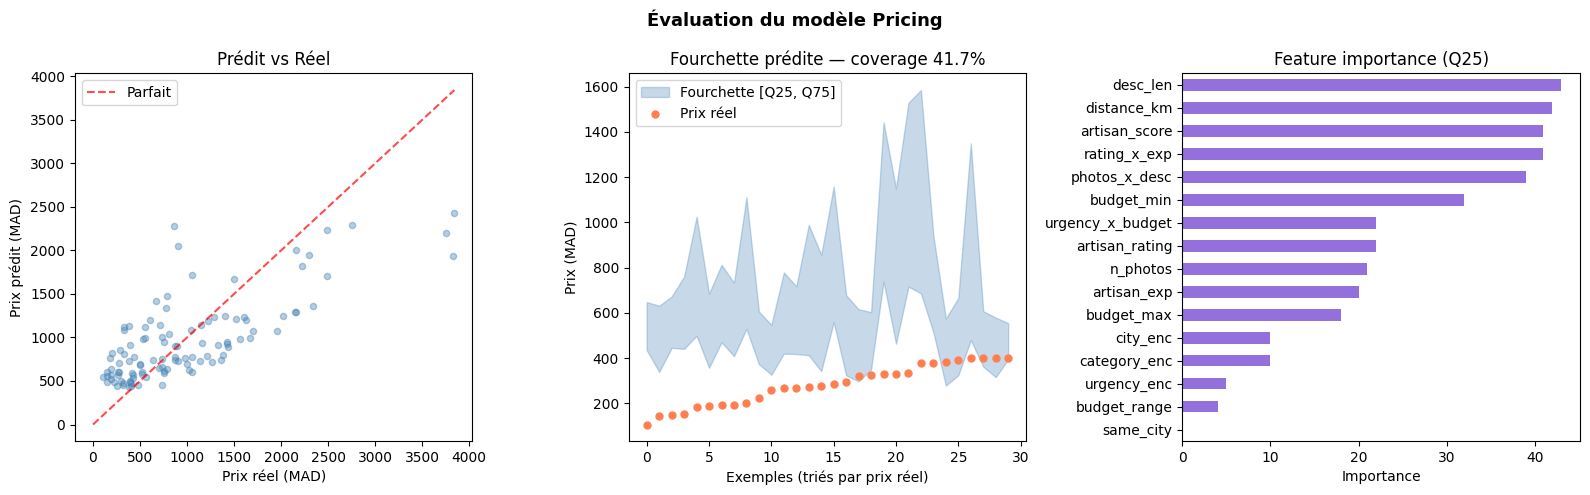

Figure sauvegardée → models/staging/pricing_evaluation.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Évaluation du modèle Pricing', fontsize=13, fontweight='bold')

# ── Graphe 1 : Prédit vs Réel ──────────────────────────────────────────────
axes[0].scatter(y_test, pred_mid, alpha=0.4, color='steelblue', s=20)
lim = max(y_test.max(), pred_mid.max())
axes[0].plot([0, lim], [0, lim], 'r--', alpha=0.7, label='Parfait')
axes[0].set_xlabel('Prix réel (MAD)')
axes[0].set_ylabel('Prix prédit (MAD)')
axes[0].set_title('Prédit vs Réel')
axes[0].legend()

# ── Graphe 2 : Fourchette Q25-Q75 sur 30 exemples ─────────────────────────
idx = np.argsort(y_test)[:30]
x_plot = np.arange(30)
axes[1].fill_between(x_plot, pred_q25[idx], pred_q75[idx],
                     alpha=0.3, color='steelblue', label='Fourchette [Q25, Q75]')
axes[1].scatter(x_plot, y_test[idx], color='coral', s=25, zorder=3, label='Prix réel')
axes[1].set_xlabel('Exemples (triés par prix réel)')
axes[1].set_ylabel('Prix (MAD)')
axes[1].set_title(f'Fourchette prédite — coverage {coverage*100:.1f}%')
axes[1].legend()

# ── Graphe 3 : Feature importance ──────────────────────────────────────────
importance = pd.Series(
    model_q25.feature_importances_,
    index=X.columns
).sort_values(ascending=True)
importance.plot(kind='barh', ax=axes[2], color='mediumpurple')
axes[2].set_title('Feature importance (Q25)')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'pricing_evaluation.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → models/staging/pricing_evaluation.png')

## 6. Test d'une prédiction réelle

Simule exactement ce que FastAPI recevra depuis Laravel.

In [11]:
# Charge le modèle sauvegardé (comme FastAPI le fera)
loaded = joblib.load(os.path.join(MODEL_DIR, 'pricing_model.pkl'))

def predict_price(category, city, urgency, desc_len, n_photos,
                  budget_min, budget_max, artisan_rating=4.0,
                  artisan_score=0.75, artisan_exp=5,
                  distance_km=10.0, same_city=1):
    """Fonction de prédiction identique à celle de FastAPI."""
    sample = pd.DataFrame([{
        'category':       category,
        'city':           city,
        'urgency':        urgency,
        'desc_len':       desc_len,
        'n_photos':       n_photos,
        'budget_min':     budget_min,
        'budget_max':     budget_max,
        'artisan_rating': artisan_rating,
        'artisan_score':  artisan_score,
        'artisan_exp':    artisan_exp,
        'distance_km':    distance_km,
        'same_city':      same_city,
    }])
    X_sample = build_features(sample)
    p_min = max(0, loaded['model_q25'].predict(X_sample)[0])
    p_max = max(p_min, loaded['model_q75'].predict(X_sample)[0])
    confidence = max(0.0, min(1.0, 1.0 - (p_max - p_min) / max(p_max, 1)))
    return round(p_min), round(p_max), round(confidence, 2)

# Test 1 : Plomberie urgente à Casablanca
p_min, p_max, conf = predict_price(
    category='Plomberie', city='Casablanca', urgency='urgent',
    desc_len=120, n_photos=2, budget_min=200, budget_max=1200
)
print(f'Test 1 — Plomberie urgente Casablanca')
print(f'  Fourchette estimée : {p_min} → {p_max} MAD')
print(f'  Confiance          : {conf}')
print()

# Test 2 : Climatisation très urgente à Rabat
p_min, p_max, conf = predict_price(
    category='Climatisation', city='Rabat', urgency='très urgent',
    desc_len=80, n_photos=1, budget_min=500, budget_max=3000
)
print(f'Test 2 — Climatisation très urgente Rabat')
print(f'  Fourchette estimée : {p_min} → {p_max} MAD')
print(f'  Confiance          : {conf}')
print()

# Test 3 : Nettoyage normal à Marrakech
p_min, p_max, conf = predict_price(
    category='Nettoyage', city='Marrakech', urgency='normal',
    desc_len=50, n_photos=0, budget_min=100, budget_max=600
)
print(f'Test 3 — Nettoyage normal Marrakech')
print(f'  Fourchette estimée : {p_min} → {p_max} MAD')
print(f'  Confiance          : {conf}')

Test 1 — Plomberie urgente Casablanca
  Fourchette estimée : 758 → 1563 MAD
  Confiance          : 0.49

Test 2 — Climatisation très urgente Rabat
  Fourchette estimée : 1334 → 2761 MAD
  Confiance          : 0.48

Test 3 — Nettoyage normal Marrakech
  Fourchette estimée : 454 → 597 MAD
  Confiance          : 0.76


## 7. Résumé et prochaine étape

In [12]:
print('=== MODÈLE PRICING ENTRAÎNÉ ===')
print()
m = loaded['metrics']
print(f'  MAE      : {m["mae"]:.1f} MAD  (erreur moyenne sur la prédiction centrale)')
print(f'  RMSE     : {m["rmse"]:.1f} MAD')
print(f'  Coverage : {m["coverage"]:.1f}%  (% de prix réels dans la fourchette prédite)')
print(f'  Width    : {m["width"]:.0f} MAD  (largeur moyenne de la fourchette)')
print()
print(f'  Modèle sauvegardé : models/staging/pricing_model.pkl')
print(f'  Run MLflow ID     : {RUN_ID}')
print()
print('Pour voir MLflow :')
print(f'  mlflow ui --backend-store-uri {MLFLOW_URI}')
print('  → ouvre http://localhost:5000')
print()
print('PROCHAINE ÉTAPE : notebooks/03_train_matching.ipynb')

=== MODÈLE PRICING ENTRAÎNÉ ===

  MAE      : 402.5 MAD  (erreur moyenne sur la prédiction centrale)
  RMSE     : 525.9 MAD
  Coverage : 41.7%  (% de prix réels dans la fourchette prédite)
  Width    : 732 MAD  (largeur moyenne de la fourchette)

  Modèle sauvegardé : models/staging/pricing_model.pkl
  Run MLflow ID     : e5b6f9f4fd3542b2a77328e8ae0f1862

Pour voir MLflow :
  mlflow ui --backend-store-uri sqlite:///c:/Users/Azzao/OneDrive/Bureau/projects/ml/mlflow_store/mlflow.db
  → ouvre http://localhost:5000

PROCHAINE ÉTAPE : notebooks/03_train_matching.ipynb
